# Lorenz System

This notebook contains the Lorenz-system experiments used in the paper, including the computation of max persistence and the $L^1$ norm of the Betti-1 curve under different noise levels.

### Block 1 — Complete definitions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
import pandas as pd
import os

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. Lorenz simulator
# ============================================================

def simulate_lorenz(
    rho,
    sigma=10.0,
    beta=8/3,
    L=100,
    fs=130,
    SampleSize=2000,
    InitialConditions=None
):
    if InitialConditions is None:
        InitialConditions = [6.74, 6.74, 22.74]

    t = np.linspace(0, L, int(L * fs))

    def lorenz(state, t):
        x, y, z = state
        dxdt = sigma * (y - x)
        dydt = x * (rho - z) - y
        dzdt = x * y - beta * z
        return dxdt, dydt, dzdt

    states = rk4_integrate(lorenz, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:],
        states[:, 2][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Plot style
# ============================================================

# Colors inherited from the Hopf style
REF_COLOR = "#1F3FFF"   # dark blue #2F5D8A
CHG_COLOR = "#D62728"   # dark red #7A1F1F
DIAG_COLOR = "#000000" # negro suavizado #111111
GRID_COLOR = "#C8C8C8"
BG_COLOR   = "#FFFFFF"
SEC_COLOR   = "#1F3FFF"
TER_COLOR   = "#2E8B57"

# Colors by noise level
NOISE_COLORS = {
    0.00: DIAG_COLOR,   # mismo estilo del caso principal en Hopf
    0.04: CHG_COLOR,   # blue
    0.10: TER_COLOR   # dark green
}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Takens embedding
# ============================================================

def getTakensEmbedding(x, dim, Tau, dT=2):
    embedder = SingleTakensEmbedding(
        parameters_type="fixed",
        time_delay=Tau,
        dimension=dim,
        stride=dT,
        n_jobs=2
    )
    return embedder.fit_transform(x)

# ============================================================
# 6. Time-series generation
# ============================================================

def generate_lorenz_series(
    rho,
    noise_level=0.0,
    sample_size=2000,
    fs=130,
    sigma=10.0,
    beta=8/3
):
    _, ts = simulate_lorenz(
        rho=rho,
        sigma=sigma,
        beta=beta,
        L=100,
        fs=fs,
        SampleSize=sample_size,
        InitialConditions=[6.74, 6.74, 22.74]
    )

    ts = add_noise(ts, noise_level=noise_level, mode="relative", seed=42)

    # solo usamos x(t)
    return np.asarray(ts[0]).ravel()

# ============================================================
# 7. Topology: max persistence + Betti L1
# ============================================================

def compute_topological_functionals_and_diagram(point_cloud, max_edge=20, n_samples=100):
    VR = VietorisRipsPersistence(
        homology_dimensions=[1],
        metric="manhattan",
        max_edge_length=max_edge
    )

    diagrams = VR.fit_transform(point_cloud[None, :, :])
    diag_H1 = diagrams[0][:, :2]

    # eliminar muertes infinitas
    diag_H1 = diag_H1[np.isfinite(diag_H1[:, 1])]

    # ---- max persistence ----
    if diag_H1.shape[0] == 0:
        max_persistence = 0.0
    else:
        persistences = diag_H1[:, 1] - diag_H1[:, 0]
        max_persistence = np.max(persistences)

    # ---- Betti-1 L1 ----
    P = np.linspace(0, max_edge, n_samples)
    betti_1 = np.zeros(n_samples)

    for i, e in enumerate(P):
        betti_1[i] = np.sum((diag_H1[:, 0] <= e) & (e < diag_H1[:, 1]))

    betti_l1 = np.sum(betti_1)

    return max_persistence, betti_l1, diag_H1

# ============================================================
# 8. Parámetros globales
# ============================================================

dim = 2
tau = 16
dT = 2
max_edge = 20
n_betti_samples = 100
rho_critico = 24.74

noise_levels = [0.00, 0.04, 0.10]

# ============================================================
# 9. Topología for un rho
# ============================================================

def compute_topology_for_rho(
    rho,
    noise_level,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge,
    n_samples=n_betti_samples
):
    serie_x = generate_lorenz_series(rho, noise_level=noise_level)
    embedding = getTakensEmbedding(serie_x, dim=dim, Tau=Tau, dT=dT)

    max_persistence, betti_l1, diag_H1 = compute_topological_functionals_and_diagram(
        embedding,
        max_edge=max_edge,
        n_samples=n_samples
    )

    return max_persistence, betti_l1, diag_H1

### Block 2 — Single precomputation

In [6]:
def precompute_lorenz_topology(
    rho_values,
    noise_levels,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge,
    n_samples=n_betti_samples
):
    results = {}

    for noise in noise_levels:
        H1_diagrams = {}
        max_persistence_values = {}
        betti_l1_values = {}

        print(f"\nPrecomputando for ruido = {noise:.2f}")

        for i, rho in enumerate(rho_values):
            mp, bl1, diag_H1 = compute_topology_for_rho(
                rho=rho,
                noise_level=noise,
                dim=dim,
                Tau=Tau,
                dT=dT,
                max_edge=max_edge,
                n_samples=n_samples
            )

            H1_diagrams[rho] = diag_H1
            max_persistence_values[rho] = mp
            betti_l1_values[rho] = bl1

            # print(f"rho = {rho:.3f} -> max persistence = {mp:.5f}, ||Bv1||_1 = {bl1:.3f} ({i+1}/{len(rho_values)})")

        results[noise] = {
            "H1_diagrams": H1_diagrams,
            "max_persistence": max_persistence_values,
            "betti_l1": betti_l1_values
        }

    return results

# ============================================================
# RUNNING THE PRECOMPUTATION
# ============================================================

rho_values = np.round(np.linspace(20, 30, 300), 3)

results = precompute_lorenz_topology(
    rho_values=rho_values,
    noise_levels=noise_levels,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge,
    n_samples=n_betti_samples
)


Precomputando para ruido = 0.00

Precomputando para ruido = 0.04

Precomputando para ruido = 0.10


### Block 3 — Plots and export

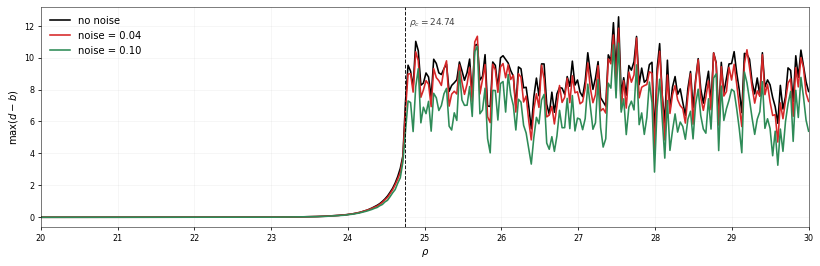


Archivo Excel guardado en:
outputs_lorenz_max_persistence/lorenz_max_persistence_rho_20_30_n300_Tau16_m2.xlsx



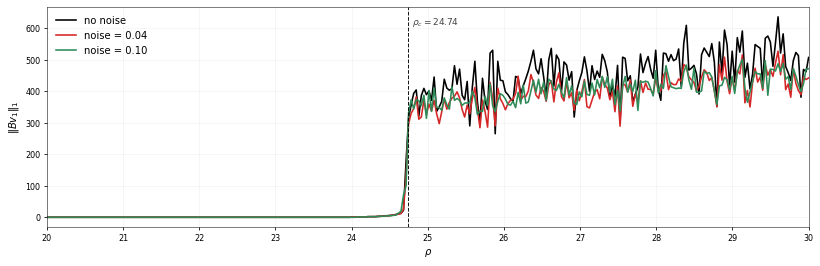


Archivo Excel guardado en:
outputs_lorenz_betti1_l1/lorenz_betti1_l1_rho_20_30_n300_Tau16_m2.xlsx



In [7]:
# ============================================================
# 1. Max persistence plot from precomputed results
# ============================================================

def plot_max_persistence_from_precomputed(
    rho_values,
    results,
    rho_critico=rho_critico,
    save_excel=True
):
    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    for noise in noise_levels:
        mp_vals = [results[noise]["max_persistence"][rho] for rho in rho_values]

        label = (
            "no noise" if noise == 0.00 else
            f"noise = {noise:.2f}"
        )

        ax.plot(
            rho_values,
            mp_vals,
            color=NOISE_COLORS[noise],
            lw=1.6,
            label=label
        )

    ax.axvline(
        rho_critico,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        rho_critico + 0.05, 0.96,
        rf"$\rho_c = {rho_critico}$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(20, 30)
    ax.set_xticks(np.arange(20, 30.01, 1.0))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$\max(d-b)$")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    fig.savefig("figure_lorenz_max_persistence_noise_comparison.png", bbox_inches="tight")
    fig.savefig("figure_lorenz_max_persistence_noise_comparison.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_lorenz_max_persistence"
        os.makedirs(carpeta, exist_ok=True)

        df = pd.DataFrame({"rho": rho_values})
        for noise in noise_levels:
            col_name = "max_persistence_noise_" + str(noise).replace(".", "_")
            df[col_name] = [results[noise]["max_persistence"][rho] for rho in rho_values]

        archivo_excel = os.path.join(
            carpeta,
            f"lorenz_max_persistence_rho_20_30_n{len(rho_values)}_Tau{tau}_m{dim}.xlsx"
        )

        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")


# ============================================================
# 2. Betti L1 plot from precomputed results
# ============================================================

def plot_betti_l1_from_precomputed(
    rho_values,
    results,
    rho_critico=rho_critico,
    save_excel=True
):
    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    for noise in noise_levels:
        bl1_vals = [results[noise]["betti_l1"][rho] for rho in rho_values]

        label = (
            "no noise" if noise == 0.00 else
            f"noise = {noise:.2f}"
        )

        ax.plot(
            rho_values,
            bl1_vals,
            color=NOISE_COLORS[noise],
            lw=1.6,
            label=label
        )

    ax.axvline(
        rho_critico,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        rho_critico + 0.05, 0.96,
        rf"$\rho_c = {rho_critico}$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(20, 30)
    ax.set_xticks(np.arange(20, 30.01, 1.0))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$\|Bv_1\|_1$")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    fig.savefig("figure_lorenz_betti1_l1_noise_comparison.png", bbox_inches="tight")
    fig.savefig("figure_lorenz_betti1_l1_noise_comparison.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_lorenz_betti1_l1"
        os.makedirs(carpeta, exist_ok=True)

        df = pd.DataFrame({"rho": rho_values})
        for noise in noise_levels:
            col_name = "betti_l1_noise_" + str(noise).replace(".", "_")
            df[col_name] = [results[noise]["betti_l1"][rho] for rho in rho_values]

        archivo_excel = os.path.join(
            carpeta,
            f"lorenz_betti1_l1_rho_20_30_n{len(rho_values)}_Tau{tau}_m{dim}.xlsx"
        )

        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")


# ============================================================
# 3. RUNNING THE PLOTS
# ============================================================

plot_max_persistence_from_precomputed(
    rho_values=rho_values,
    results=results,
    rho_critico=rho_critico,
    save_excel=True
)

plot_betti_l1_from_precomputed(
    rho_values=rho_values,
    results=results,
    rho_critico=rho_critico,
    save_excel=True
)